In [41]:
pip install STL

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [56]:
from statsmodels.tsa.seasonal import STL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [43]:
df = pd.read_csv(r"D:\laper men\datathon_dani\inflasiwatch\data\final\output_clean\df_clean.csv")

In [44]:
df.head()

,date,kota,month,month_sin,month_cos,ihk_kel_01_mtm,ihk_kel_03_mtm,ihk_kel_06_mtm,gt_harga_beras,gt_harga_cabai,...,gt_harga_bensin_lag3_pct_change,kota_jakarta,kota_makassar,kota_medan,kota_surabaya,ihk_umum_mtm,inflasi_general_mtm,inflasi_core_mtm,inflasi_administered_price_mtm,inflasi_volatile_good_mtm
0,2020-02-01,bandung,2,8.660254e-01,5.000000e-01,1.28,0.05,-0.72,51,42,...,-0.111111,0,0,0,0,0.32,0.28,0.14,-0.11,1.27
1,2020-03-01,bandung,3,1.000000e+00,6.120000e-17,0.95,0.00,-0.60,57,34,...,-0.111111,0,0,0,0,0.01,0.10,0.29,-0.19,-0.38
2,2020-04-01,bandung,4,8.660254e-01,-5.000000e-01,0.41,0.00,-0.38,87,50,...,-0.111111,0,0,0,0,-0.16,0.08,0.17,-0.14,-0.09
3,2020-05-01,bandung,5,5.000000e-01,-8.660254e-01,-0.97,0.00,0.12,78,42,...,-0.111111,0,0,0,0,0.21,0.07,0.06,0.67,-0.50
4,2020-06-01,bandung,6,1.220000e-16,-1.000000e+00,1.43,0.00,0.34,70,36,...,-0.093750,0,0,0,0,0.28,0.18,0.02,0.22,0.77


In [45]:
df['kota'].value_counts()

kota
bandung     74
jakarta     74
makassar    74
medan       74
surabaya    74
Name: count, dtype: int64

In [46]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})
 
KOTA_LIST   = ["bandung", "jakarta", "makassar", "medan", "surabaya"]
KOTA_COLORS = {"bandung": "#9467bd", "jakarta": "#1f77b4", "makassar": "#d62728",
                "medan": "#2ca02c", "surabaya": "#ff7f0e"}

INFLASI_COLS = {
    "General"           : "inflasi_general_mtm",
    "Core"              : "inflasi_core_mtm",
    "Volatile Good"     : "inflasi_volatile_good_mtm",
    "Administered Price": "inflasi_administered_price_mtm",
}
 
KOMODITAS_COLS = {
    "Beras"      : "gt_harga_beras",
    "Cabai"      : "gt_harga_cabai",
    "Telur"      : "gt_harga_telur",
    "Daging Ayam": "gt_harga_daging_ayam",
    "Minyak Goreng": "gt_harga_minyak_goreng",
    "Bawang"     : "gt_harga_bawang",
}

In [47]:
# Ganti path sesuai lokasi file CSV kamu
df = df.sort_values("date").reset_index(drop=True)
 
# Pastikan kolom kota ada (one-hot → string)
if "kota" not in df.columns:
    kota_cols = [c for c in df.columns if c.startswith("kota_")]
    df["kota"] = df[kota_cols].idxmax(axis=1).str.replace("kota_", "")
 
df["date"] = pd.to_datetime(df["date"])
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month
df_nat = df.drop_duplicates("date").sort_values("date").reset_index(drop=True)

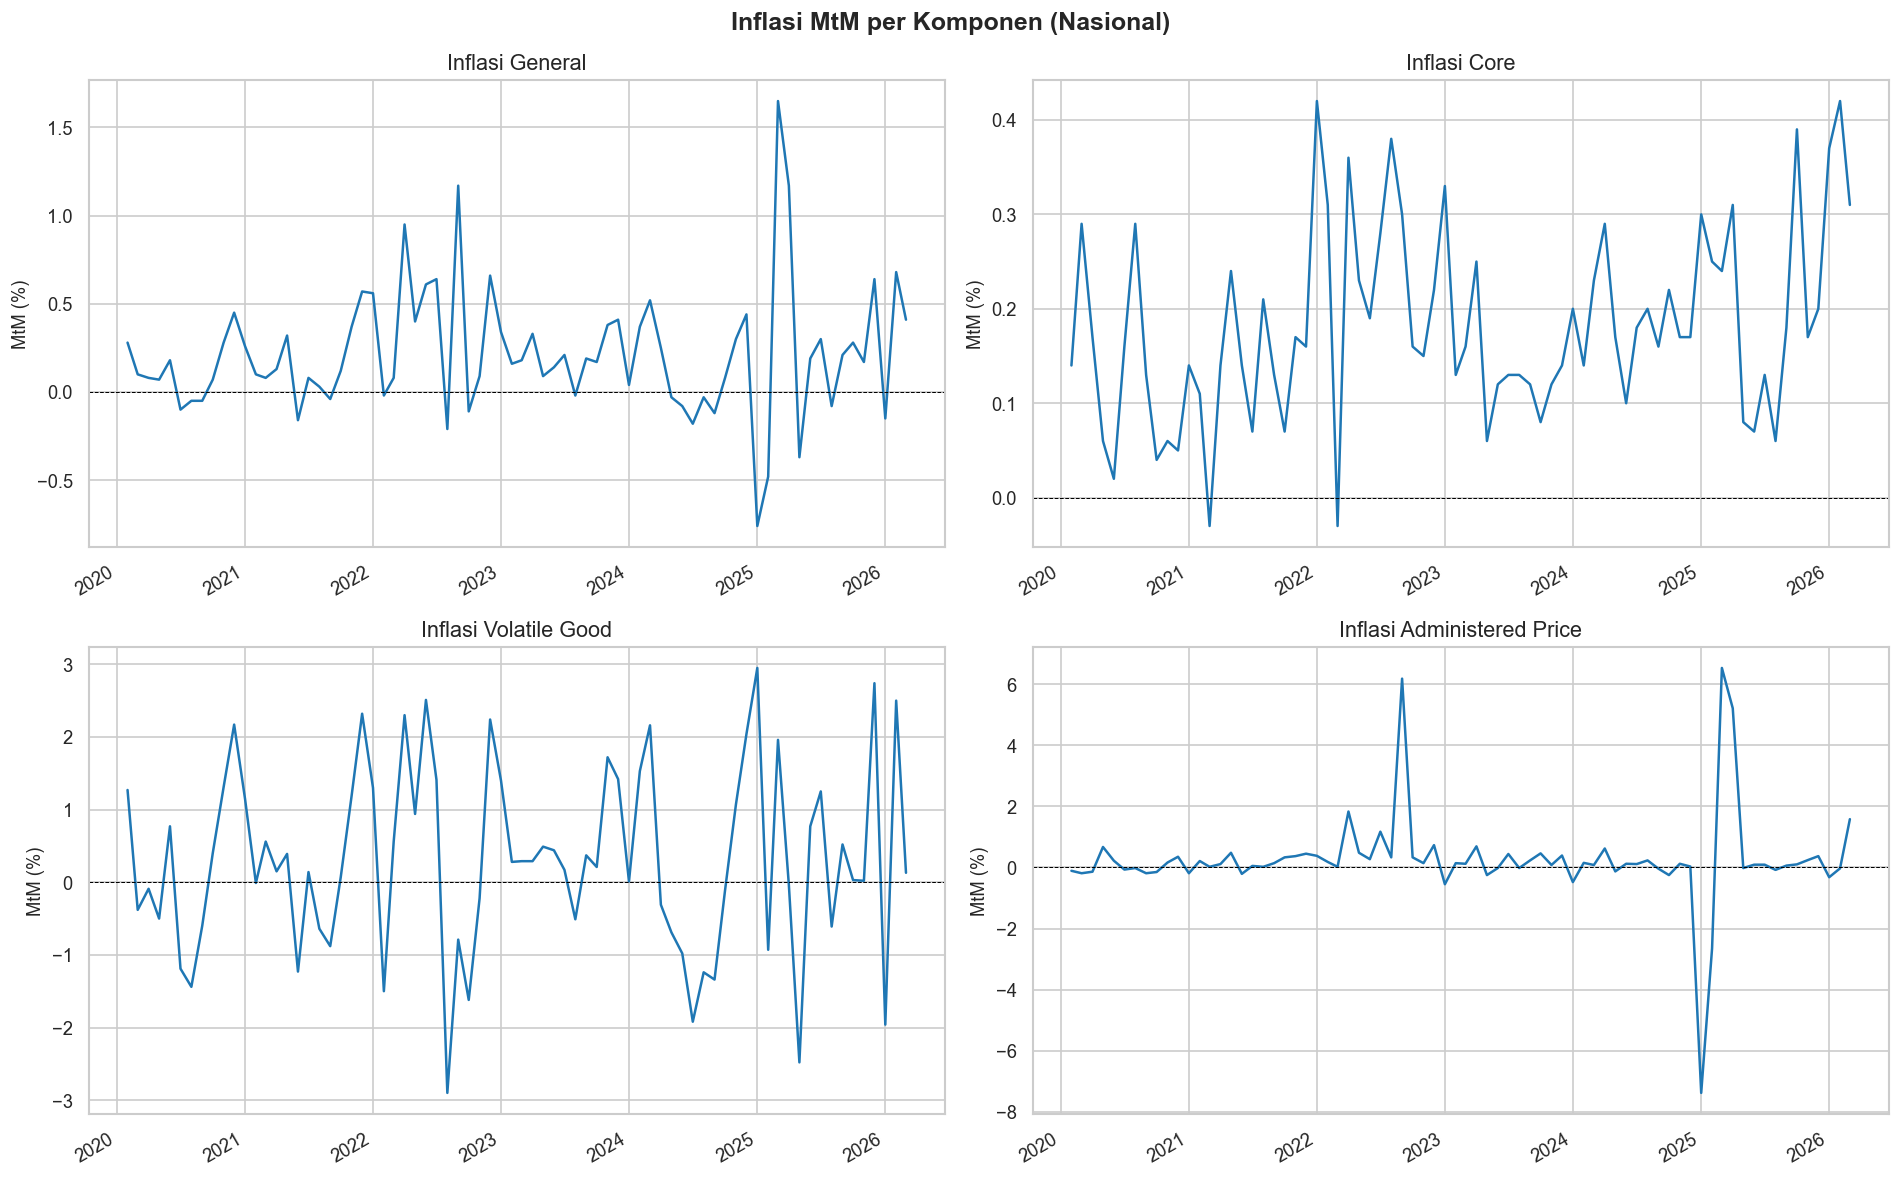

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Inflasi MtM per Komponen (Nasional)", fontsize=15, fontweight="bold")

for ax, (label, col) in zip(axes.flat, INFLASI_COLS.items()):
    ax.plot(df_nat["date"], df_nat[col], linewidth=1.5, color="#1f77b4")
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(f"Inflasi {label}")
    ax.set_ylabel("MtM (%)")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("01_line_inflasi.png", bbox_inches="tight")
plt.show()

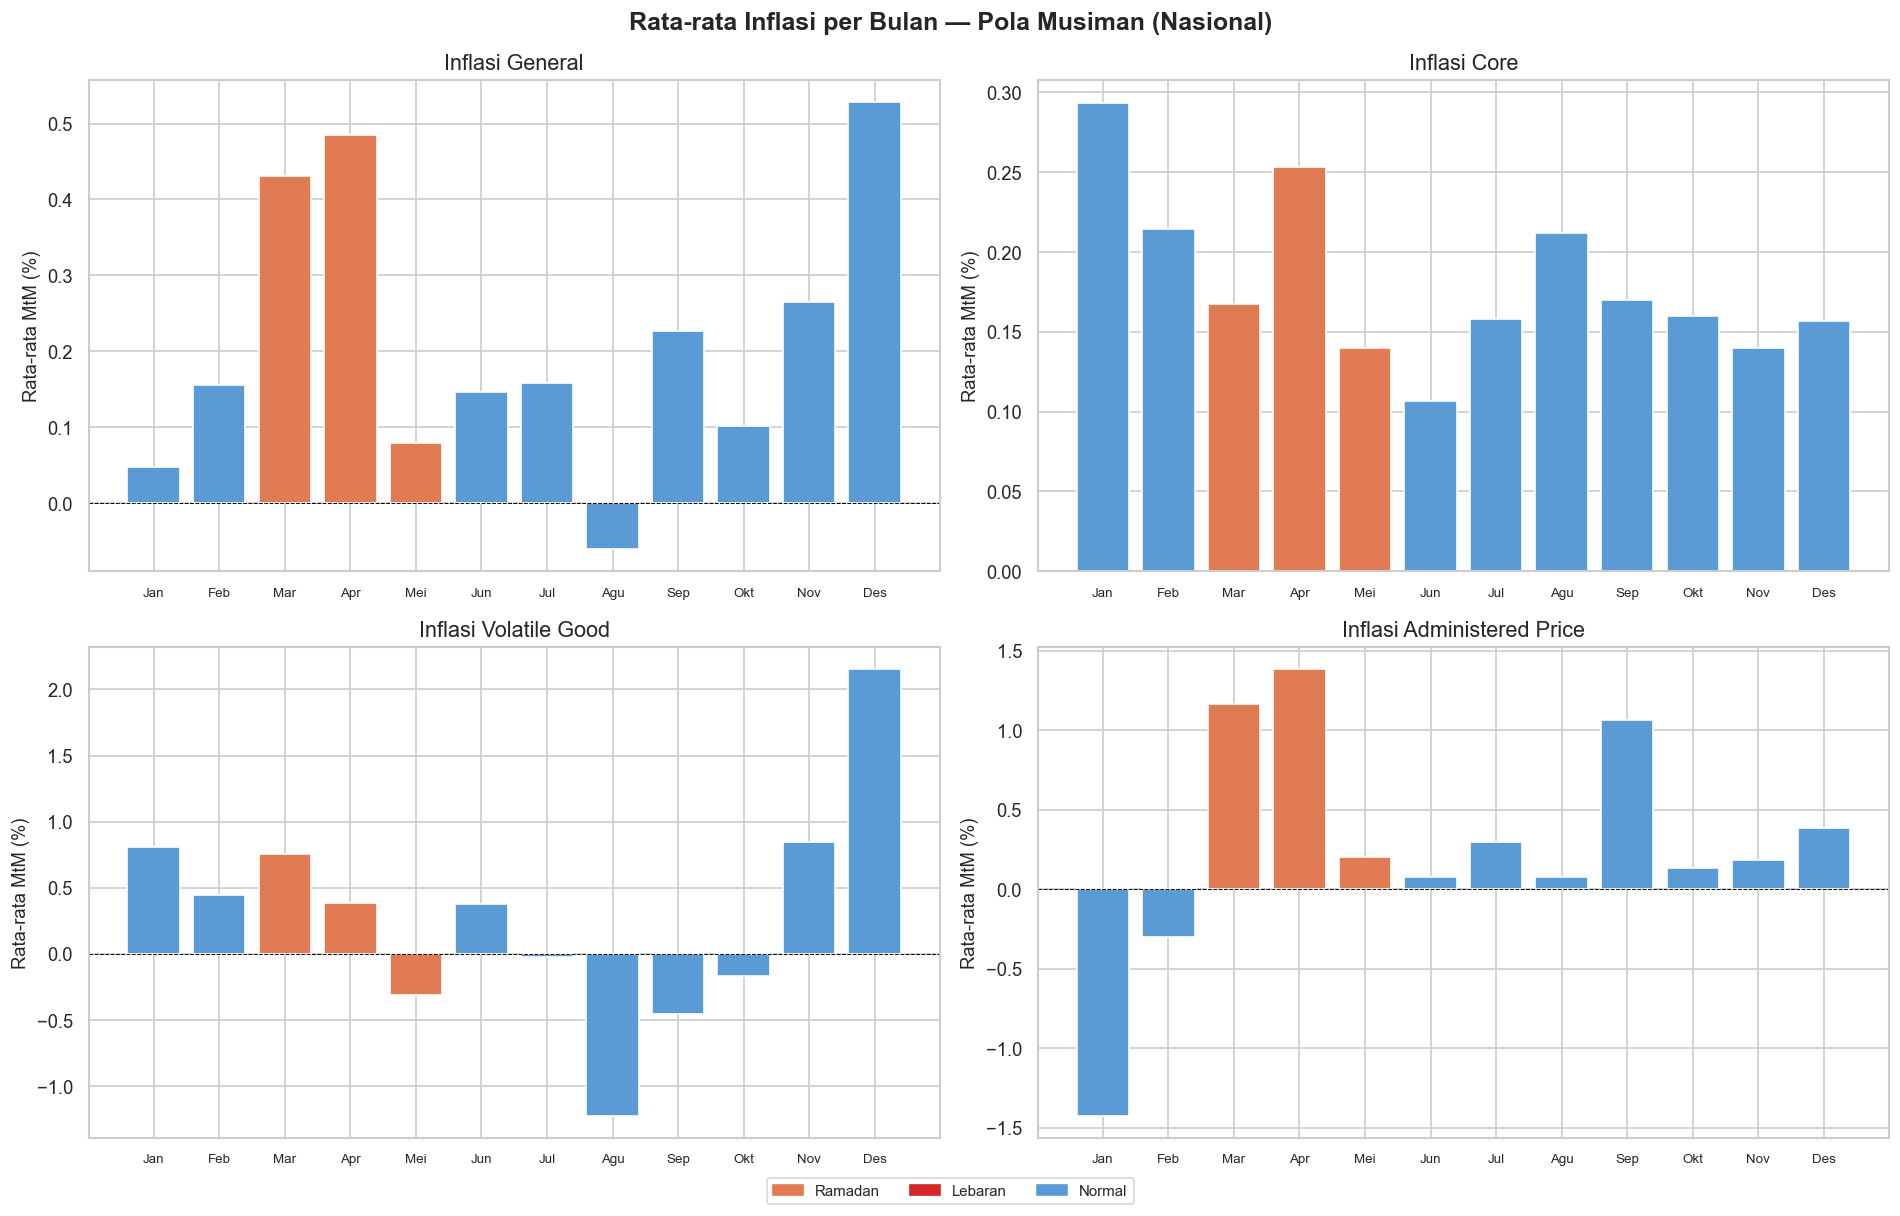

In [49]:
ramadan_months = df_nat.groupby("month")["is_ramadan"].mean()
lebaran_months = df_nat.groupby("month")["is_lebaran"].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Rata-rata Inflasi per Bulan — Pola Musiman (Nasional)",
             fontsize=15, fontweight="bold")

for ax, (label, col) in zip(axes.flat, INFLASI_COLS.items()):
    monthly = df_nat.groupby("month")[col].mean()
    colors  = ["#e07b54" if ramadan_months[m] > 0.3
               else "#d62728" if lebaran_months[m] > 0.3
               else "#5b9bd5" for m in monthly.index]
    ax.bar(monthly.index, monthly.values, color=colors, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(f"Inflasi {label}")
    ax.set_ylabel("Rata-rata MtM (%)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(bulan_label, fontsize=8)

from matplotlib.patches import Patch
legend_els = [Patch(color="#e07b54", label="Ramadan"),
              Patch(color="#d62728", label="Lebaran"),
              Patch(color="#5b9bd5", label="Normal")]
fig.legend(handles=legend_els, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("04_seasonality_ramadan.png", bbox_inches="tight")
plt.show()

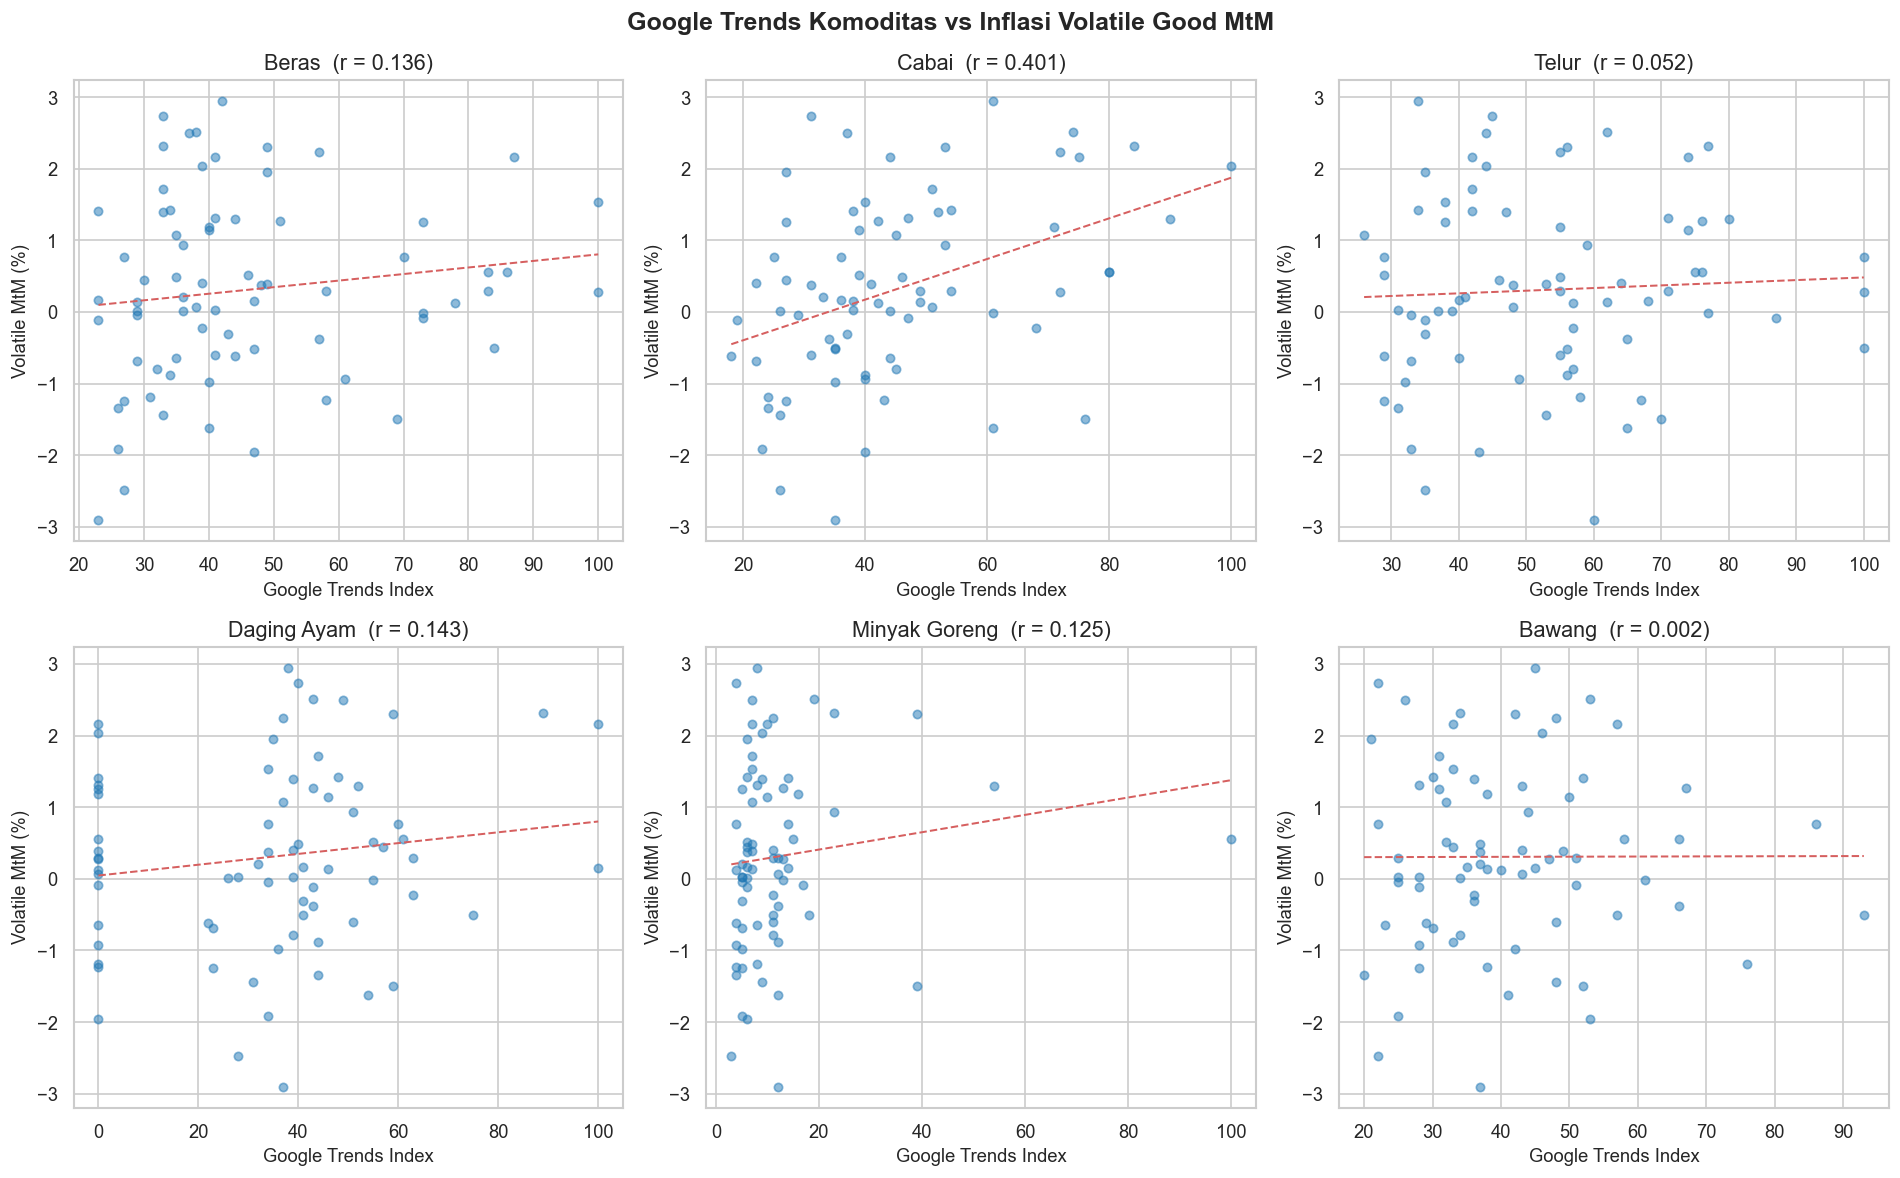

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Google Trends Komoditas vs Inflasi Volatile Good MtM",
             fontsize=15, fontweight="bold")

for ax, (label, col) in zip(axes.flat, KOMODITAS_COLS.items()):
    valid = df_nat[[col, "inflasi_volatile_good_mtm"]].dropna()
    ax.scatter(valid[col], valid["inflasi_volatile_good_mtm"],
               alpha=0.5, s=25, color="#1f77b4")
    z = np.polyfit(valid[col], valid["inflasi_volatile_good_mtm"], 1)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=1.2)
    corr = valid.corr().iloc[0, 1]
    ax.set_title(f"{label}  (r = {corr:.3f})")
    ax.set_xlabel("Google Trends Index")
    ax.set_ylabel("Volatile MtM (%)")

plt.tight_layout()
plt.savefig("05_scatter_komoditas.png", bbox_inches="tight")
plt.show()

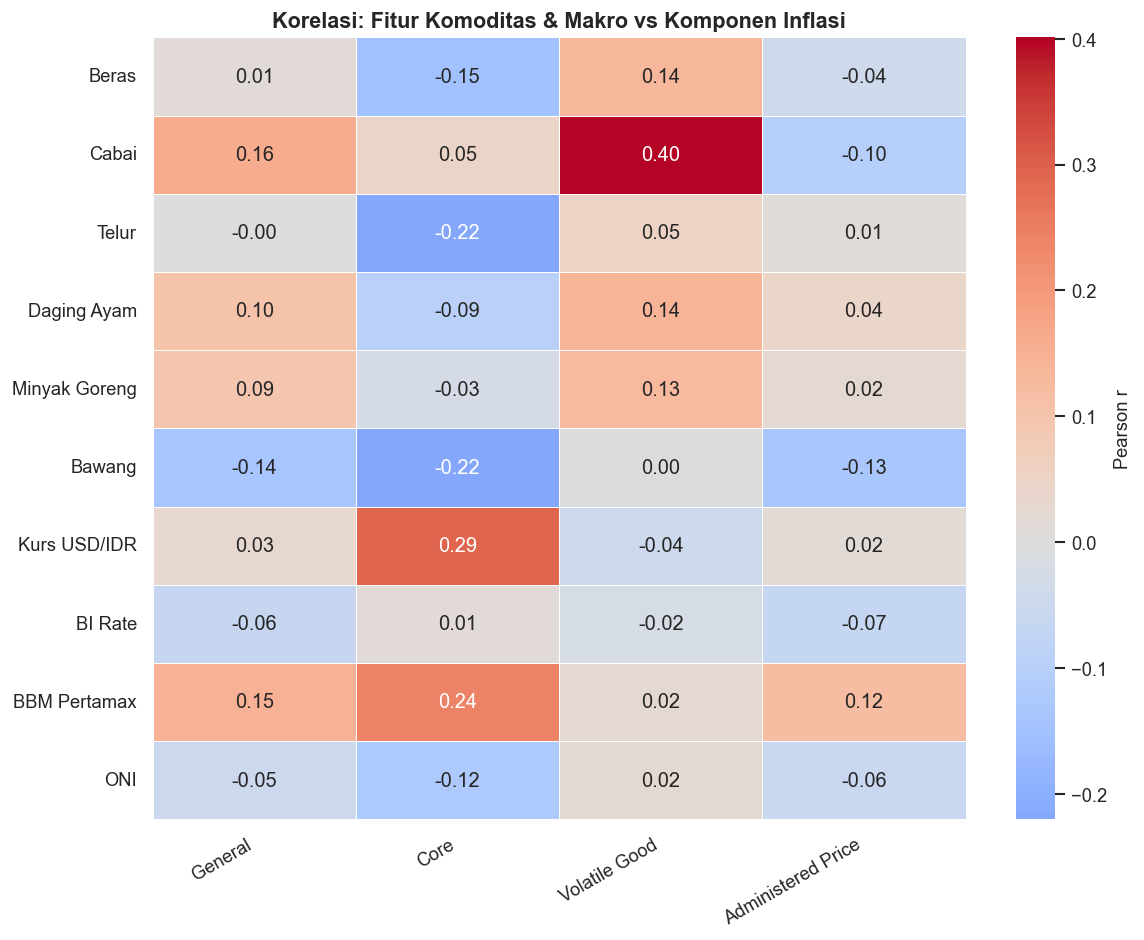

In [51]:
feature_cols = list(KOMODITAS_COLS.values()) + [
    "kurs_usd_idr", "bi_rate_percent", "harga_bbm_pertamax", "oceanic_nino_index"
]
target_cols = list(INFLASI_COLS.values())

corr_df = df_nat[feature_cols + target_cols].corr().loc[feature_cols, target_cols]
feature_labels = list(KOMODITAS_COLS.keys()) + ["Kurs USD/IDR","BI Rate","BBM Pertamax","ONI"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, ax=ax, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            xticklabels=list(INFLASI_COLS.keys()),
            yticklabels=feature_labels,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Korelasi: Fitur Komoditas & Makro vs Komponen Inflasi",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("06_correlation_heatmap.png", bbox_inches="tight")
plt.show()

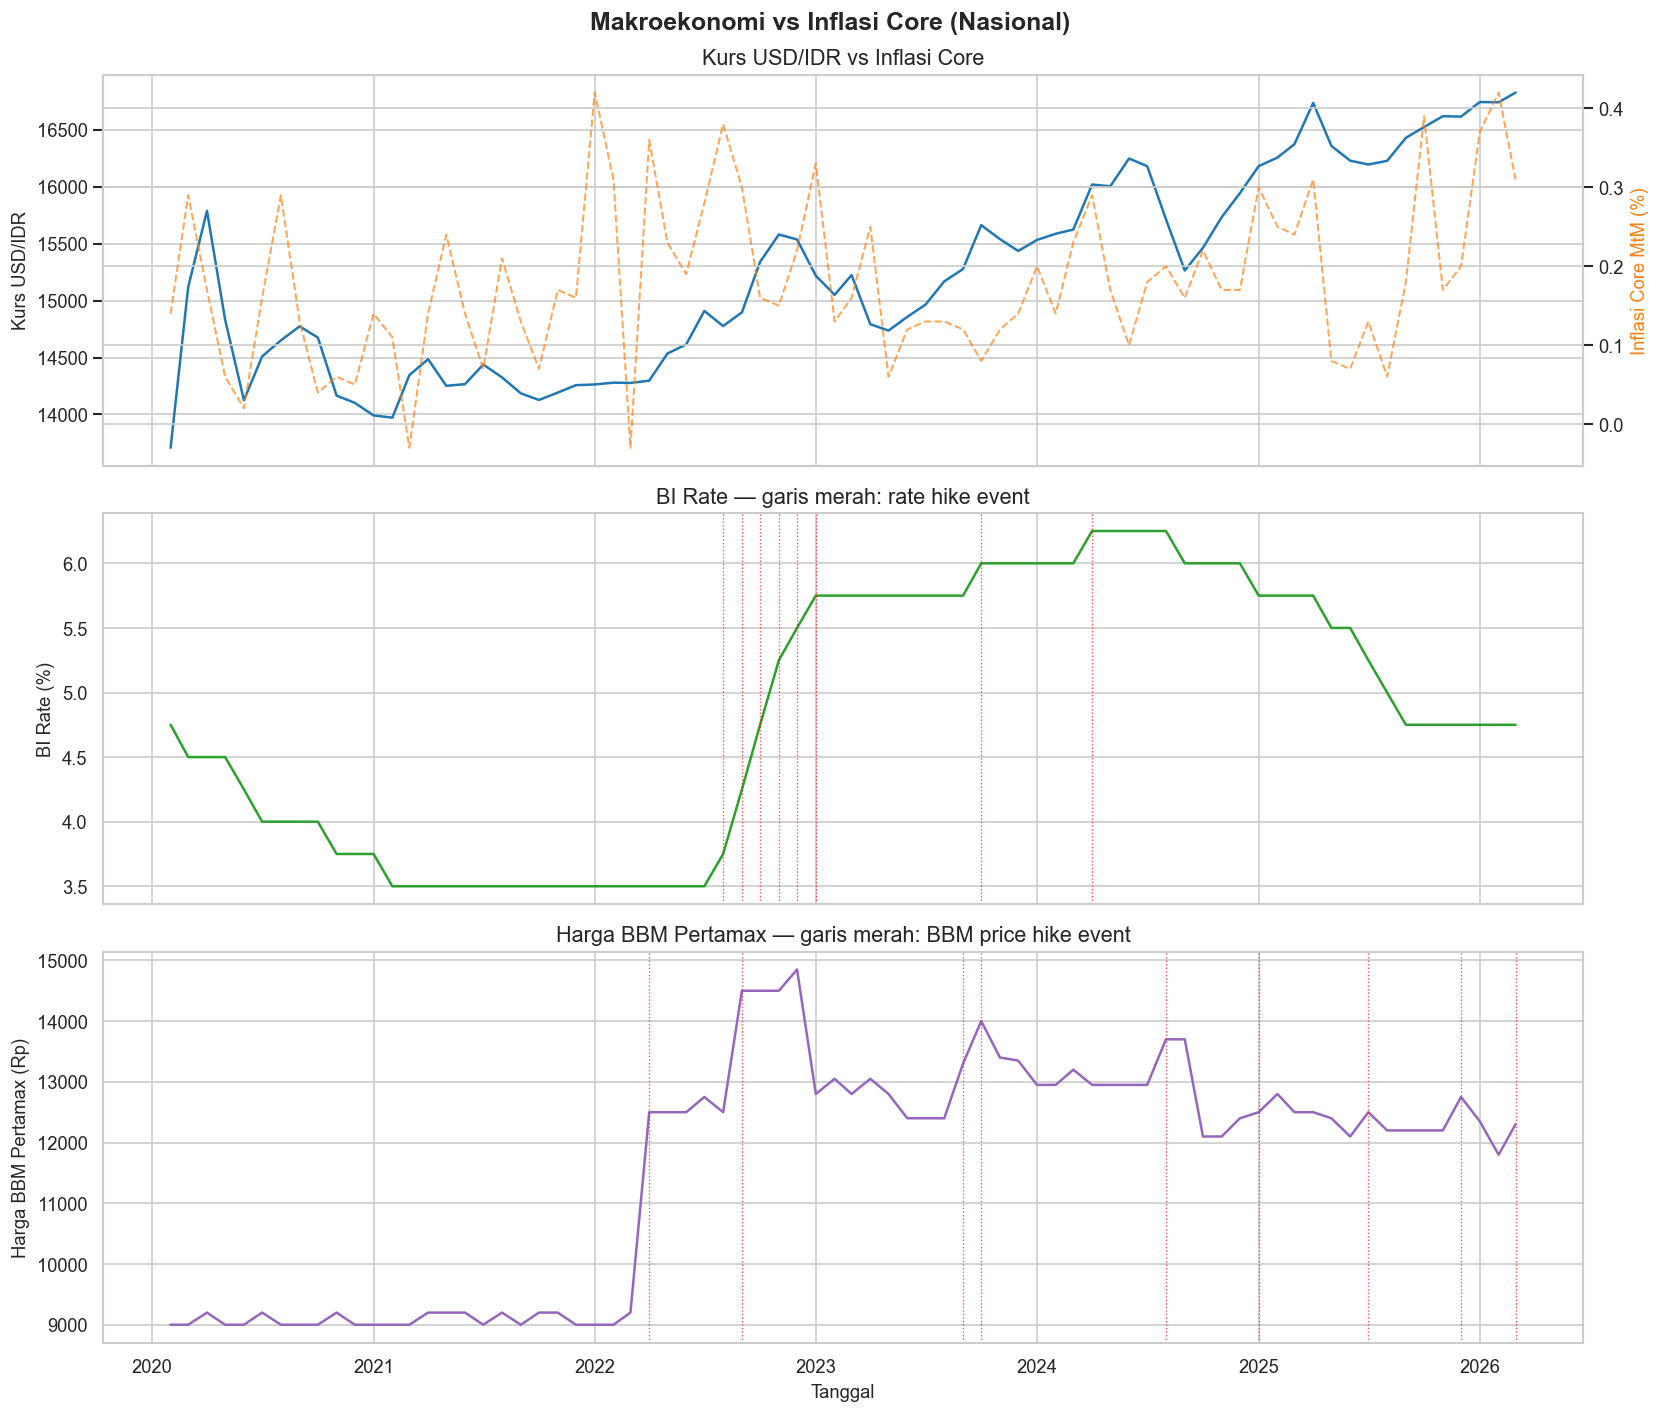

In [52]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Makroekonomi vs Inflasi Core (Nasional)", fontsize=15, fontweight="bold")

ax1 = axes[0]
ax1.plot(df_nat["date"], df_nat["kurs_usd_idr"], color="#1f77b4", linewidth=1.5)
ax1.set_ylabel("Kurs USD/IDR")
ax1b = ax1.twinx()
ax1b.plot(df_nat["date"], df_nat["inflasi_core_mtm"], color="#ff7f0e",
          linewidth=1.2, linestyle="--", alpha=0.7)
ax1b.set_ylabel("Inflasi Core MtM (%)", color="#ff7f0e")
ax1.set_title("Kurs USD/IDR vs Inflasi Core")

ax2 = axes[1]
ax2.plot(df_nat["date"], df_nat["bi_rate_percent"], color="#2ca02c", linewidth=1.5)
for d in df_nat[df_nat["bi_rate_hike_event"] == 1]["date"]:
    ax2.axvline(d, color="red", linewidth=0.8, linestyle=":", alpha=0.7)
ax2.set_ylabel("BI Rate (%)")
ax2.set_title("BI Rate — garis merah: rate hike event")

ax3 = axes[2]
ax3.plot(df_nat["date"], df_nat["harga_bbm_pertamax"], color="#9467bd", linewidth=1.5)
for d in df_nat[df_nat["bbm_price_hike_event"] == 1]["date"]:
    ax3.axvline(d, color="red", linewidth=0.8, linestyle=":", alpha=0.7)
ax3.set_ylabel("Harga BBM Pertamax (Rp)")
ax3.set_title("Harga BBM Pertamax — garis merah: BBM price hike event")
ax3.set_xlabel("Tanggal")

plt.tight_layout()
plt.savefig("07_makroekonomi_event.png", bbox_inches="tight")
plt.show()

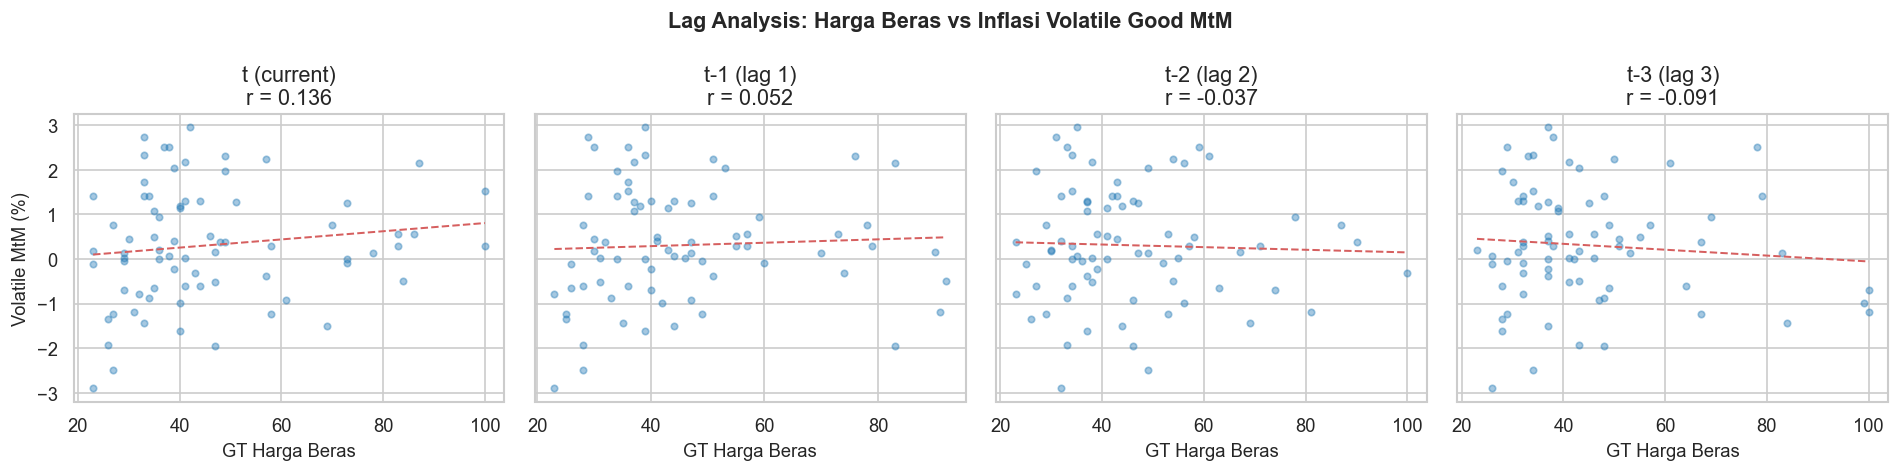

In [53]:
lag_cols   = ["gt_harga_beras","gt_harga_beras_lag1",
              "gt_harga_beras_lag2","gt_harga_beras_lag3"]
lag_labels = ["t (current)","t-1 (lag 1)","t-2 (lag 2)","t-3 (lag 3)"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Lag Analysis: Harga Beras vs Inflasi Volatile Good MtM",
             fontsize=13, fontweight="bold")

for ax, col, label in zip(axes, lag_cols, lag_labels):
    valid = df_nat[[col, "inflasi_volatile_good_mtm"]].dropna()
    ax.scatter(valid[col], valid["inflasi_volatile_good_mtm"],
               alpha=0.4, s=15, color="#1f77b4")
    corr = valid.corr().iloc[0, 1]
    z    = np.polyfit(valid[col], valid["inflasi_volatile_good_mtm"], 1)
    x_l  = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_l, np.poly1d(z)(x_l), "r--", linewidth=1.2)
    ax.set_title(f"{label}\nr = {corr:.3f}")
    ax.set_xlabel("GT Harga Beras")
axes[0].set_ylabel("Volatile MtM (%)")

plt.tight_layout()
plt.savefig("10_lag_analysis_beras.png", bbox_inches="tight")
plt.show()

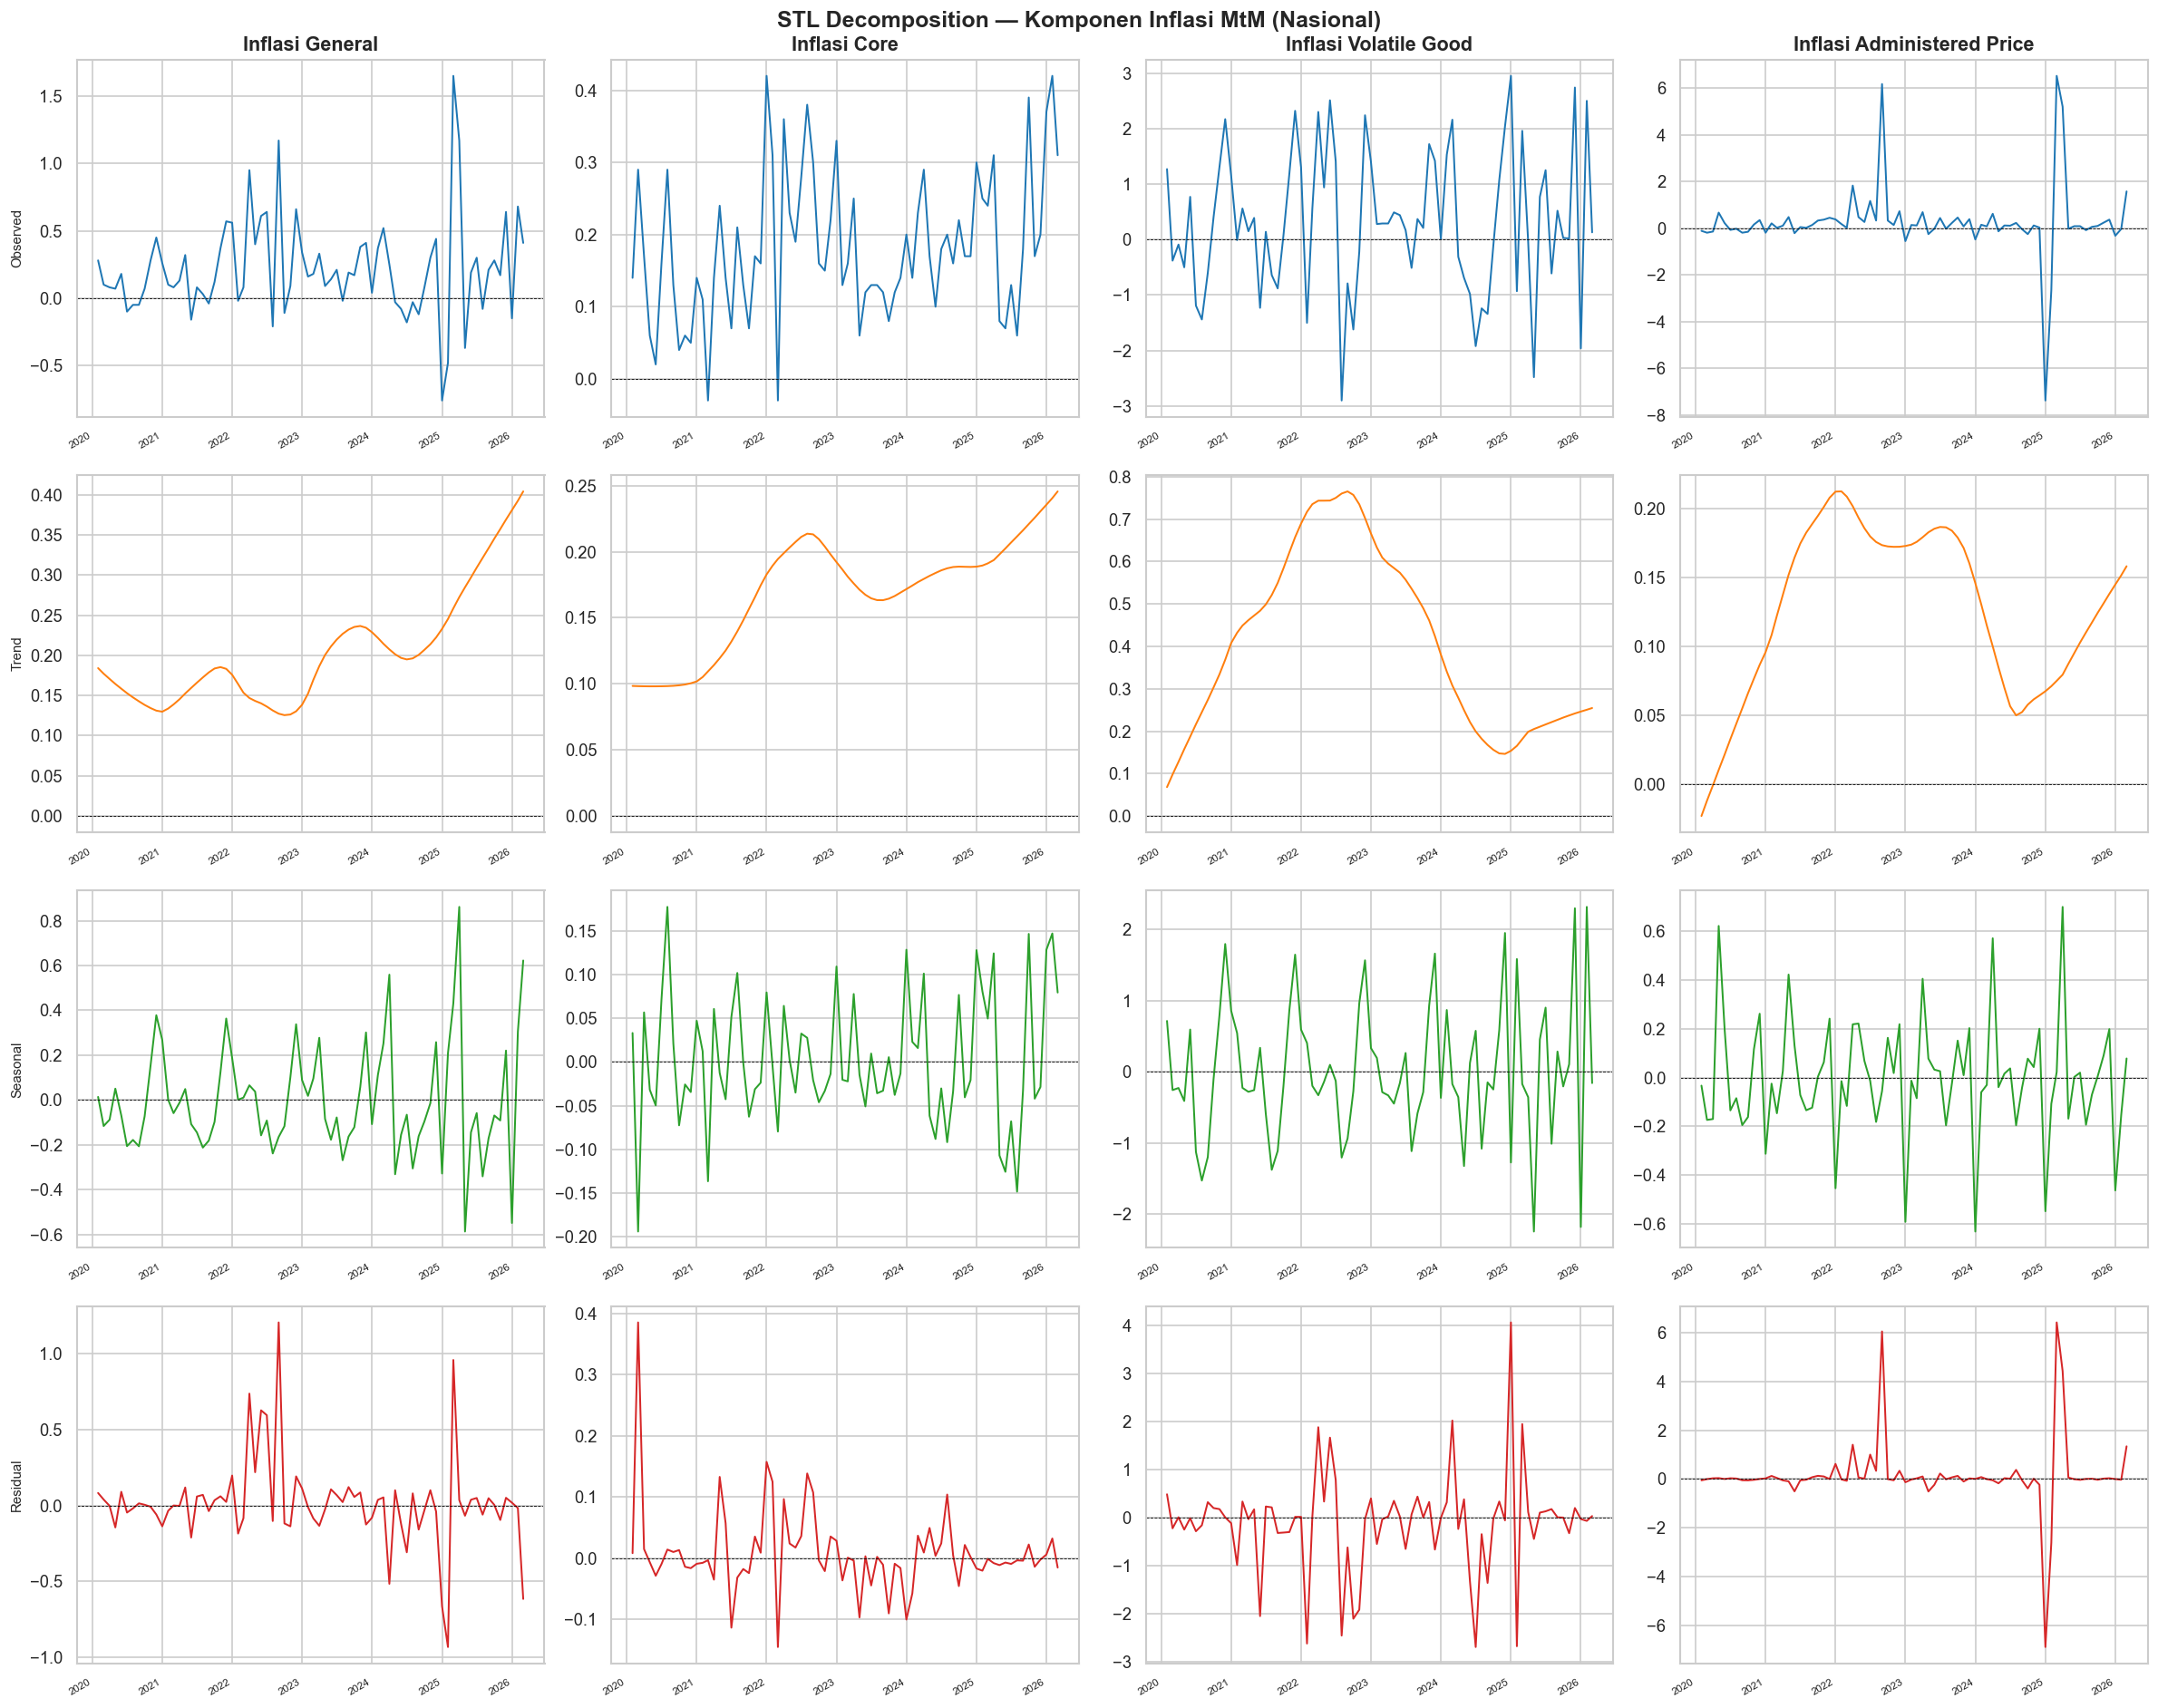

In [57]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle("STL Decomposition — Komponen Inflasi MtM (Nasional)",
             fontsize=15, fontweight="bold")

for col_idx, (label, col) in enumerate(INFLASI_COLS.items()):
    series = df_nat.set_index("date")[col].dropna()
    stl    = STL(series, period=12, robust=True).fit()

    row_data = [("Observed", series),
                ("Trend",    stl.trend),
                ("Seasonal", stl.seasonal),
                ("Residual", stl.resid)]

    for row_idx, (comp_label, comp_data) in enumerate(row_data):
        ax = axes[row_idx][col_idx]
        color = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"][row_idx]
        ax.plot(comp_data.index, comp_data.values, color=color, linewidth=1.2)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        if row_idx == 0:
            ax.set_title(f"Inflasi {label}", fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(comp_label, fontsize=9)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

plt.tight_layout()
plt.savefig("11_stl_decomposition.png", bbox_inches="tight")
plt.show()